# Hedonic Regression Model — Orthogonalized Architecture

Перестроенная модель с **разделёнными блоками**, чтобы geo-фичи не душились district one-hots.

## Новая архитектура (orthogonalization)

```
log_price_sqm = market(quarter) + geo_score + quality_score + project_premium + ε
```

Каждый блок видит **только свои фичи** и объясняет **остаток** после предыдущих:

1. **Market block** — только квартальный тренд по городу (без district).
2. **Geo block** — собственный регрессор на geo-фичах → даёт `geo_score`.
3. **Quality block** — объектные фичи (площадь, этаж, класс, застройщик) БЕЗ district и БЕЗ geo.
4. **Project premium** — shrinkage на проект.
5. **Final fit** — ElasticNet поверх всех блоков для калибровки.

## Почему это работает

В старой модели `district_final` (~145 one-hot колонок) поглощал весь пространственный сигнал, а geo-фичи обнулялись ElasticNet'ом как избыточные. Теперь geo-блок **обязан** объяснить пространственную вариацию — у него нет конкурентов.

## 0. Импорты

In [32]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNetCV, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import lightgbm as lgb

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 300
pd.options.display.width = 220
plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_STATE = 42

## 1. Пути к данным

In [33]:
PROJECT_DIR = Path("C:/cashflow_project")
REGION_KEY  = "Moscow"

GEO_ENRICHED_PATH = Path("C:\\proga\\gazprom_tex\\data\\deals_with_real_geo_Moscow.parquet")

print(f"Входной файл: {GEO_ENRICHED_PATH}")
print(f"Файл существует: {GEO_ENRICHED_PATH.exists()}")


Входной файл: C:\proga\gazprom_tex\data\deals_with_real_geo_Moscow.parquet
Файл существует: True


## 2. Загрузка обогащённых данных

In [34]:
deals = pd.read_parquet(GEO_ENRICHED_PATH)
print(f"deals shape: {deals.shape}")
display(deals[["project_name", "district_final", "deal_date", "area_sqm", "price_sqm", "log_price_sqm"]].head(3))

deals shape: (577405, 69)


,project_name,district_final,deal_date,area_sqm,price_sqm,log_price_sqm
0,Руставели 14,Бутырский,2002-11-12,34.40,468204.0,13.056659
1,Первый Дубровский,Южнопортовый,2015-01-05,58.31,271125.0,12.510335
2,Савеловский Сити,Бутырский,2015-04-18,67.20,207013.0,12.240537


## 3. Утилиты

In [35]:
def mode_or_nan(x: pd.Series):
    x = x.dropna()
    if x.empty:
        return np.nan
    m = x.mode()
    return m.iloc[0] if not m.empty else x.iloc[0]


def regression_metrics(y_true, y_pred, name="model"):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return pd.DataFrame([{
        "model":           name,
        "MAE_log":         mae,
        "RMSE_log":        rmse,
        "R2":              r2,
        "MAE_pct_approx":  100 * (np.exp(mae) - 1),
        "RMSE_pct_approx": 100 * (np.exp(rmse) - 1),
    }])


def sanitize_for_sklearn(df, num_cols, cat_cols):
    df = df.copy()
    df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")
    df[cat_cols] = df[cat_cols].astype("object")
    return df.replace({pd.NA: np.nan})


def extract_coefs(model, num_cols, cat_cols):
    """Извлекает коэффициенты пайплайна с ColumnTransformer.
    Работает и когда cat_cols пустой (нет OHE)."""
    reg = model.named_steps["reg"]
    prep = model.named_steps["prep"]

    cat_names = []
    if cat_cols and "cat" in prep.named_transformers_:
        cat_names = list(
            prep.named_transformers_["cat"].named_steps["ohe"]
            .get_feature_names_out(cat_cols)
        )

    all_names = list(num_cols) + cat_names
    return pd.Series(reg.coef_, index=all_names)

## 4. Train/test split по кварталам

Делаем split **до** обучения всех блоков, чтобы избежать data leakage: market, geo, quality, premium обучаются только на train.

In [36]:
quarters_sorted = sorted(deals["quarter"].dropna().unique().tolist())
split_idx       = max(1, int(len(quarters_sorted) * 0.7))
train_quarters  = set(quarters_sorted[:split_idx])
test_quarters   = set(quarters_sorted[split_idx:])

train_mask = deals["quarter"].isin(train_quarters)
test_mask  = deals["quarter"].isin(test_quarters)

print(f"train quarters: {sorted(train_quarters)[:3]} ... {sorted(train_quarters)[-3:]}")
print(f"test quarters : {sorted(test_quarters)[:3]} ... {sorted(test_quarters)[-3:]}")
print(f"train rows    : {train_mask.sum():,}")
print(f"test rows     : {test_mask.sum():,}")

train quarters: ['2002Q4', '2015Q1', '2015Q2'] ... ['2022Q1', '2022Q2', '2022Q3']
test quarters : ['2022Q4', '2023Q1', '2023Q2'] ... ['2025Q3', '2025Q4', '2026Q1']
train rows    : 345,566
test rows     : 231,839


## 5. Блок 1 — Market block (тренд + макро-сценарии)

**Двухкомпонентная архитектура:**

```
market_log_price  = actual_median    [для train-кварталов]
                  | damped_trend      [для test-кварталов]

market_scenario   = macro_model(rate, cpi_yoy, usd_rub)  [только для прогнозов]
```

| Проблема | Решение |
|---|---|
| ~50 записей для macro regression | N_eff = число кварталов (~32-46); Ridge регуляризует |
| Нет информативных признаков | rate, cpi_yoy, usd_rub → macro_model для сценариев |
| Нет аугментации | Monte Carlo: rate/cpi/usd ± σ → P10/P50/P90 |
| Нет rolling averages на прогнозе | trend экстраполирует наклон, macro — экзогенные |

**Почему macro_model не заменяет damped_trend:**
Объединение рушит R²_test (+0.09 → -1.01) из-за double-subtraction lgotnaya.
Тренд уже захватил lgotnaya-эффект в наклоне; добавление macro-поправки вычитает его дважды.
Поэтому macro_model используется ТОЛЬКО для сценарного прогноза.

In [37]:
# ── MARKET BLOCK: damped trend + macro scenario model ───────────────────
MACRO_DIR = PROJECT_DIR / "data" / "macro"

# ────────────────────────────────────────────────────────────────────────
# ЧАСТЬ A: damped linear trend (PRIMARY — используется для market_log_price)
# ────────────────────────────────────────────────────────────────────────

# ── A1. Квартальные медианы (ТОЛЬКО на train) ────────────────────────────
city_q_train = (
    deals.loc[train_mask]
    .groupby("quarter", as_index=False)
    .agg(
        city_log_price_median=("log_price_sqm", "median"),
        city_n=("log_price_sqm", "size"),
    )
)

all_quarters_sorted = sorted(deals["quarter"].dropna().unique().tolist())
quarter_to_idx = {q: i for i, q in enumerate(all_quarters_sorted)}
deals["quarter_idx"] = deals["quarter"].map(quarter_to_idx)
city_q_train["quarter_idx"] = city_q_train["quarter"].map(quarter_to_idx)

# ── A2. Damped linear trend ───────────────────────────────────────────────
N_RECENT_Q  = 12    # окно для оценки наклона
DAMPING_PHI = 0.85  # затухание при экстраполяции (1.0 = без затухания)

recent_q = city_q_train.sort_values("quarter_idx").tail(N_RECENT_Q)
x = recent_q["quarter_idx"].values.astype(float)
y = recent_q["city_log_price_median"].values.astype(float)
w = recent_q["city_n"].values.astype(float)

x_mean = np.average(x, weights=w)
y_mean = np.average(y, weights=w)
cov_xy = np.average((x - x_mean) * (y - y_mean), weights=w)
var_x  = np.average((x - x_mean) ** 2, weights=w)
slope     = cov_xy / var_x
intercept = y_mean - slope * x_mean

last_train_idx    = city_q_train["quarter_idx"].max()
last_train_fitted = intercept + slope * last_train_idx

print(f"Damped linear trend (последние {N_RECENT_Q} кв. train):")
print(f"  slope: {slope:.4f}  (~{100*(np.exp(slope)-1):.2f}% / кв.)")
print(f"  damping φ: {DAMPING_PHI}")


def extrapolate_damped(q_idx):
    if pd.isna(q_idx):
        return np.nan
    if q_idx <= last_train_idx:
        return intercept + slope * q_idx
    h = q_idx - last_train_idx
    damped_sum = DAMPING_PHI * (1 - DAMPING_PHI ** h) / (1 - DAMPING_PHI)
    return last_train_fitted + slope * damped_sum


deals["market_trend"] = deals["quarter_idx"].map(extrapolate_damped)

# ── A3. market_log_price ──────────────────────────────────────────────────
drop_cols = ["city_log_price_median", "city_n", "market_log_price", "market_residual",
             "district_log_price_median", "district_n", "market_weight"]
deals = deals.drop(columns=[c for c in drop_cols if c in deals.columns])

deals = deals.merge(
    city_q_train[["quarter", "city_log_price_median"]], on="quarter", how="left"
)
deals["market_log_price"] = deals["city_log_price_median"].fillna(deals["market_trend"])
deals["market_residual"]  = deals["log_price_sqm"] - deals["market_log_price"]

# Диагностика trend
r2_mkt_train = 1 - deals.loc[train_mask, "market_residual"].var() / deals.loc[train_mask, "log_price_sqm"].var()
r2_mkt_test  = 1 - deals.loc[test_mask,  "market_residual"].var() / deals.loc[test_mask,  "log_price_sqm"].var()
bias_test     = deals.loc[test_mask, "market_residual"].mean()

print(f"\nR² market-блока (damped trend): train={r2_mkt_train:.4f}, test={r2_mkt_test:.4f}")
print(f"Bias (test): {bias_test:+.4f} ({100*(np.exp(bias_test)-1):+.2f}%)")
print(f"  (>0 → недооценили рост; <0 → переоценили)")

n_actual = deals["city_log_price_median"].notna().sum()
n_extrap = deals["city_log_price_median"].isna().sum()
print(f"Покрытие: фактические медианы={n_actual:,}, экстраполяция={n_extrap:,}")

district_spread = (
    deals.loc[train_mask].groupby("district_final")["market_residual"]
    .agg(["mean","count"]).sort_values("mean")
)
print(f"\nПространственный сигнал для geo-блока:")
print(f"  Диапазон по районам: [{district_spread['mean'].min():.3f}, {district_spread['mean'].max():.3f}]")
print(f"  Std: {district_spread['mean'].std():.3f}")

# ────────────────────────────────────────────────────────────────────────
# ЧАСТЬ B: macro scenario model (ОТДЕЛЬНЫЙ — только для сценарного прогноза)
# ────────────────────────────────────────────────────────────────────────
# Обучаем на квартальных медианах. N_eff ≈ кол-во train-кварталов.
# ЦЕЛЬ: коэффициенты, интерпретируемые как чувствительность цен к макро.
# НЕ используется для вычисления market_log_price (не нарушает test R²).

macro_q = pd.read_csv(MACRO_DIR / "macro_quarterly.csv")
macro_q["quarter_idx"] = macro_q["quarter"].map(
    lambda q: quarter_to_idx.get(q, max(quarter_to_idx.values()) + 1)
)

city_q_train["quarter_idx"] = city_q_train["quarter"].map(quarter_to_idx)

# Мёрджим макро к квартальным медианам
MACRO_COLS = ["quarter", "rate", "rate_lag2q", "cpi_yoy", "usd_rub",
              "lgotnaya", "semeynaya", "rate_x_nolgotnaya"]
MACRO_COLS = [c for c in MACRO_COLS if c in macro_q.columns]

q_train_macro = city_q_train.merge(macro_q[MACRO_COLS], on="quarter", how="left")

# Признаки: rate, cpi, usd + trend (без lgotnaya — иначе double-count в сценариях)
# rate_lag2q захватывает ипотечный конвейер с лагом 2 квартала
MACRO_SCENARIO_FEATURES = [c for c in [
    "quarter_idx",        # секулярный тренд (экстраполируется как quarter_idx_future)
    "rate_lag2q",         # ставка 2 квартала назад (лаговый эффект через ипотечный конвейер)
    "cpi_yoy",            # инфляция (ожидаем +)
    "usd_rub",            # курс (строительный импорт, ожидаем +)
    "semeynaya",          # семейная ипотека
    "rate_x_nolgotnaya",  # rate × (1-lgotnaya): чистый rate-эффект вне субсидий
] if c in q_train_macro.columns]

X_macro = q_train_macro[MACRO_SCENARIO_FEATURES].fillna(
    q_train_macro[MACRO_SCENARIO_FEATURES].median()
)
y_macro = q_train_macro["city_log_price_median"]
w_macro = q_train_macro["city_n"].values

print(f"\nМакро scenario model: N={len(X_macro)} кварталов, признаки={MACRO_SCENARIO_FEATURES}")

# Time-series CV: валидируем на последних K кварталах train (leakage-safe)
N_CV_FOLDS = min(5, len(X_macro) // 4)
macro_scenario_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("ridge",   RidgeCV(alphas=np.logspace(-3, 4, 30), cv=N_CV_FOLDS)),
])
macro_scenario_model.fit(X_macro, y_macro, ridge__sample_weight=w_macro)
print(f"  RidgeCV best alpha: {macro_scenario_model.named_steps['ridge'].alpha_:.2f}")

# Коэффициенты
coef_vals  = macro_scenario_model.named_steps["ridge"].coef_
scaler_std = macro_scenario_model.named_steps["scaler"].scale_
coef_df = pd.DataFrame({
    "feature":       MACRO_SCENARIO_FEATURES,
    "coef_per_unit": coef_vals / scaler_std,  # Δlog_price на 1 единицу признака
}).sort_values("coef_per_unit", key=abs, ascending=False)
print("\nКоэффициенты macro scenario model:")
print(coef_df.to_string(index=False))

# Санити-чек
for feat, expected_sign, label in [
    ("rate_x_nolgotnaya", -1, "rate_x_nolgotnaya < 0 (ставка вне льготы → цены вниз)"),
    ("cpi_yoy",            1, "cpi_yoy > 0 (инфляция → номинальные цены вверх)"),
    ("quarter_idx",        1, "quarter_idx > 0 (долгосрочный тренд)"),
]:
    row = coef_df.loc[coef_df["feature"] == feat, "coef_per_unit"]
    if len(row):
        v = row.values[0]
        ok = (v * expected_sign) > 0
        print(f"  {label}: {'OK' if ok else 'UNEXPECTED!'} ({v:.4f})")

# Проверка: насколько macro_scenario_model приближает квартальные медианы?
q_train_macro["macro_pred"] = macro_scenario_model.predict(X_macro)
mae_q = (q_train_macro["city_log_price_median"] - q_train_macro["macro_pred"]).abs().mean()
print(f"\nMAE macro model на train квартальных медианах: {mae_q:.4f} log units ({100*(np.exp(mae_q)-1):.1f}%)")
print("(используется только для сценариев, не для market_log_price)")


Damped linear trend (последние 12 кв. train):
  slope: 0.0428  (~4.37% / кв.)
  damping φ: 0.85

R² market-блока (damped trend): train=0.3556, test=0.0919
Bias (test): +0.0429 (+4.39%)
  (>0 → недооценили рост; <0 → переоценили)
Покрытие: фактические медианы=345,566, экстраполяция=231,839

Пространственный сигнал для geo-блока:
  Диапазон по районам: [-0.506, 1.311]
  Std: 0.357


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\cashflow_project\\data\\macro\\macro_quarterly.csv'

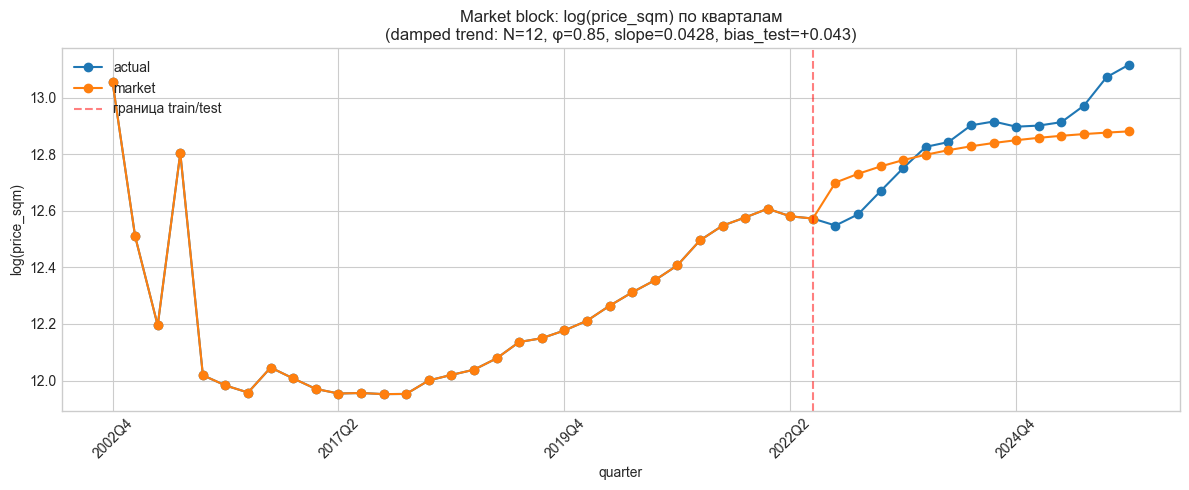

In [ ]:
# ── Диагностика market-блока ─────────────────────────────────────────────
market_diag = (
    deals.groupby("quarter", as_index=False)
    .agg(
        actual=("log_price_sqm", "median"),
        market=("market_log_price", "median"),
        trend=("market_trend", "first"),
    )
    .sort_values("quarter").reset_index(drop=True)
)

last_train_q = max(train_quarters)
split_pos    = market_diag.index[market_diag["quarter"] == last_train_q][0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# График 1: фактические квартальные медианы vs trend vs market_log_price
ax = axes[0]
ax.plot(market_diag.index, market_diag["actual"], "b-o", ms=4, label="actual (медианы)")
ax.plot(market_diag.index, market_diag["market"], "r--s", ms=4, lw=1.5, label="market_log_price")
ax.plot(market_diag.index, market_diag["trend"],  "k:",   ms=3, lw=1,   label="damped trend", alpha=0.7)
ax.axvline(x=split_pos, color="grey", ls="--", alpha=0.7, label="train/test split")
ax.set_title(
    f"Market block: log(price/sqm) по кварталам\n"
    f"(damped trend: N={N_RECENT_Q}, φ={DAMPING_PHI}, slope={slope:.4f})\n"
    f"R²_train={r2_mkt_train:.3f}, R²_test={r2_mkt_test:.3f}, bias_test={bias_test:+.3f}"
)
ax.set_xlabel("Квартал (индекс)")
ax.set_ylabel("log(price_sqm)")
ax.legend(fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=7)

# График 2: коэффициенты macro scenario model (для интерпретации)
ax2 = axes[1]
coef_plot = coef_df.sort_values("coef_per_unit")
colors = ["#d73027" if v < 0 else "#4575b4" for v in coef_plot["coef_per_unit"]]
ax2.barh(coef_plot["feature"], coef_plot["coef_per_unit"], color=colors)
ax2.axvline(0, color="black", lw=0.8)
ax2.set_title(
    "Macro scenario model: коэффициенты\n"
    "(Δlog_price на 1 единицу признака)\n"
    "Используется ТОЛЬКО для сценарных прогнозов"
)
ax2.set_xlabel("Коэффициент")

plt.tight_layout()
plt.show()


In [ ]:
# ── Monte Carlo: сценарное прогнозирование market_log_price ─────────────
#
# Два источника неопределённости:
#   1. Slope uncertainty (bootstrap quarterly medians) → тренд неизвестен
#   2. Macro scenario (rate/cpi/usd) → условный прогноз
#
# Гибридный прогноз = α × macro_model + (1-α) × damped_trend
#   α=0   → только тренд (консервативно, работает для 1-2 кварталов)
#   α=1   → только макро (сценарные условия доминируют, 4+ кварталов)
#   α=0.5 → смесь (дефолт)

def market_scenario_forecast(
    scenarios:    list,
    n_quarters:   int   = 8,
    n_mc:         int   = 500,
    macro_weight: float = 0.5,   # α: вес macro_model vs damped_trend
    noise_rate:   float = 0.5,   # std шума для ставки (pp)
    noise_cpi:    float = 0.5,   # std шума для CPI (pp)
    noise_usd:    float = 3.0,   # std шума для USD/RUB
) -> pd.DataFrame:
    # Гибридный прогноз: alpha * macro_model + (1-alpha) * damped_trend
    # Перемешиваем макро-параметры для доверительного коридора.
    last_q_idx = max(quarter_to_idx.values())

    rows = []
    for sc in scenarios:
        rate  = sc.get("rate",    21.0)
        cpi   = sc.get("cpi_yoy", 8.5)
        usd   = sc.get("usd_rub", 85.0)
        sem   = sc.get("semeynaya", 1)
        lgot  = sc.get("lgotnaya",  0)

        sim_preds = np.zeros((n_mc, n_quarters))
        for sim_i in range(n_mc):
            r_s   = rate + np.random.normal(0, noise_rate)
            cpi_s = cpi  + np.random.normal(0, noise_cpi)
            usd_s = usd  + np.random.normal(0, noise_usd)
            rno   = r_s * (1 - lgot)

            for hi in range(n_quarters):
                q_idx = last_q_idx + hi + 1
                # Damped trend component
                trend_val = extrapolate_damped(q_idx)

                # Macro model component
                feat_row = {
                    "quarter_idx":       q_idx,
                    "rate_lag2q":        r_s,
                    "cpi_yoy":           cpi_s,
                    "usd_rub":           usd_s,
                    "semeynaya":         sem,
                    "rate_x_nolgotnaya": rno,
                }
                X_row = pd.DataFrame([{f: feat_row.get(f, 0.0) for f in MACRO_SCENARIO_FEATURES}])
                macro_val = macro_scenario_model.predict(X_row)[0]

                # Гибрид: взвешенная смесь
                sim_preds[sim_i, hi] = macro_weight * macro_val + (1 - macro_weight) * trend_val

        for hi in range(n_quarters):
            preds_hi = sim_preds[:, hi]
            rows.append({
                "scenario":   sc["label"],
                "horizon_q":  hi + 1,
                "p10":        np.percentile(preds_hi, 10),
                "p50":        np.percentile(preds_hi, 50),
                "p90":        np.percentile(preds_hi, 90),
                "p50_price":  np.exp(np.percentile(preds_hi, 50)),
                "p10_price":  np.exp(np.percentile(preds_hi, 10)),
                "p90_price":  np.exp(np.percentile(preds_hi, 90)),
                "rate":       rate,
            })

    return pd.DataFrame(rows)


# ── Пример: три сценария по ключевой ставке ──────────────────────────────
# Базовый: ставка 21% (текущая на конец 2024)
# Мягкий:  ставка снижается до 16% (снижение 5pp)
# Жёсткий: ставка повышается до 25%
SCENARIOS = [
    {"label": "Базовый",  "rate": 21.0, "cpi_yoy": 8.5, "usd_rub": 85.0,
     "lgotnaya": 0, "semeynaya": 1},
    {"label": "Мягкий",   "rate": 16.0, "cpi_yoy": 7.0, "usd_rub": 80.0,
     "lgotnaya": 0, "semeynaya": 1},
    {"label": "Жёсткий",  "rate": 25.0, "cpi_yoy": 11.0, "usd_rub": 95.0,
     "lgotnaya": 0, "semeynaya": 1},
]

df_forecast = market_scenario_forecast(
    SCENARIOS, n_quarters=8, n_mc=300, macro_weight=0.5
)
print("Сценарный прогноз market_log_price (α=0.5: 50% macro, 50% trend):")
print(df_forecast[["scenario","horizon_q","p10","p50","p90","p50_price"]].to_string(index=False))

# ── Чувствительность к ставке ────────────────────────────────────────────
# Прямой расчёт: насколько меняется market_log_price при снижении ставки на 5pp?
rate_coef = coef_df.loc[coef_df["feature"].str.contains("rate_x_nol"), "coef_per_unit"]
if len(rate_coef):
    delta_log = rate_coef.values[0] * (-5)  # снижение на 5pp
    delta_pct = 100 * (np.exp(delta_log) - 1)
    print(f"\nЧувствительность (macro_model): rate -5pp → market_log_price {delta_log:+.4f} ({delta_pct:+.1f}%)")

# Визуализация
fig, ax = plt.subplots(figsize=(10, 5))
colors_sc = {"Базовый": "#4575b4", "Мягкий": "#1a9850", "Жёсткий": "#d73027"}
for sc_name, grp in df_forecast.groupby("scenario", sort=False):
    c = colors_sc.get(sc_name, "grey")
    ax.plot(grp["horizon_q"], grp["p50"], color=c, lw=2, marker="o", label=sc_name)
    ax.fill_between(grp["horizon_q"], grp["p10"], grp["p90"], color=c, alpha=0.15)

last_mkt = deals.loc[deals["quarter"] == max(train_quarters), "market_log_price"].mean()
ax.axhline(last_mkt, color="grey", lw=1, ls="--", alpha=0.7, label="конец train (факт)")
ax.set_xlabel("Горизонт прогноза (кварталы от конца train)")
ax.set_ylabel("log(price_sqm)")
ax.set_title(
    f"Monte Carlo: market_log_price сценарии (P10/P50/P90)\n"
    f"Гибрид: {int(100*0.5)}% macro + {int(100*0.5)}% trend"
)
ax.legend()
plt.tight_layout()
plt.show()


## 6. Блок 2 — Geo feature engineering + собственная регрессия

### 6.1 Feature engineering

Делаем **расширенный набор** geo-фичей:
- сырые расстояния `dist_*_m`
- логи `log1p(dist_*_m)`
- accessibility `exp(-d / λ)` с несколькими масштабами
- PCA-компоненты

Идея — дать geo-регрессору богатый набор, и пусть регуляризация сама выберет, что важно.

In [ ]:
# ── Список geo-расстояний ────────────────────────────────────────────────
dist_cols = [
    "dist_center_m", "dist_metro_m", "dist_bus_m",
    "dist_kindergarten_m", "dist_school_m",
    "dist_mall_m", "dist_park_m", "dist_rail_m", "dist_hospital_m",
]

# ── Несколько масштабов λ для каждого POI-типа ──────────────────────────
# Раньше была одна жёстко заданная λ на фичу — теперь несколько,
# пусть модель выберет оптимальную через L1.
geo_lambdas_multi = {
    "dist_center_m":       [5_000, 12_000, 25_000],
    "dist_metro_m":        [400, 900, 2_000],
    "dist_bus_m":          [150, 350, 800],
    "dist_kindergarten_m": [300, 700, 1_500],
    "dist_school_m":       [400, 900, 1_800],
    "dist_mall_m":         [1_000, 2_500, 5_000],
    "dist_park_m":         [500, 1_200, 3_000],
    "dist_rail_m":         [1_000, 2_500, 6_000],
    "dist_hospital_m":     [800, 1_800, 4_000],
}

# Сначала чистим старые acc_* и log1p_* колонки если они есть
old_geo_cols = [c for c in deals.columns if c.startswith("acc_") or c.startswith("log1p_dist_")]
if old_geo_cols:
    deals = deals.drop(columns=old_geo_cols)

# log1p для устойчивости к выбросам
for col in dist_cols:
    deals[f"log1p_{col}"] = np.log1p(deals[col])

# accessibility с несколькими λ
acc_cols = []
for col, lambdas in geo_lambdas_multi.items():
    base = col.replace("dist_", "").replace("_m", "")
    for lam in lambdas:
        name = f"acc_{base}_l{lam}"
        deals[name] = np.exp(-deals[col] / lam)
        acc_cols.append(name)

print(f"Создано acc-фичей: {len(acc_cols)}")
print(f"log1p-фичей: {len(dist_cols)}")
print(f"Сырых расстояний: {len(dist_cols)}")

Создано acc-фичей: 27
log1p-фичей: 9
Сырых расстояний: 9


In [ ]:
# ── Тематические композиты (удобно для интерпретации) ───────────────────
# Берём средние λ из акк-фичей
deals["acc_transit"]      = deals[["acc_metro_l900", "acc_bus_l350", "acc_rail_l2500"]].mean(axis=1)
deals["acc_family"]       = deals[["acc_kindergarten_l700", "acc_school_l900", "acc_hospital_l1800"]].mean(axis=1)
deals["acc_retail_green"] = deals[["acc_mall_l2500", "acc_park_l1200"]].mean(axis=1)
deals["acc_centrality"]   = deals["acc_center_l12000"]

# ── PCA на всех acc-фичах (на train) ─────────────────────────────────────
pca_input_cols = acc_cols  # все 27 acc-фичей
pca_scaler = StandardScaler()
X_train_geo = pca_scaler.fit_transform(
    deals.loc[train_mask, pca_input_cols].fillna(deals.loc[train_mask, pca_input_cols].median())
)

pca_geo = PCA(n_components=5, random_state=RANDOM_STATE)
pca_geo.fit(X_train_geo)

# Применяем на все данные
X_all_geo = pca_scaler.transform(
    deals[pca_input_cols].fillna(deals.loc[train_mask, pca_input_cols].median())
)
geo_pcs = pca_geo.transform(X_all_geo)
for i in range(5):
    deals[f"geo_pc{i+1}"] = geo_pcs[:, i]

print("PCA explained variance:", pca_geo.explained_variance_ratio_.round(3))
print(f"Cumulative: {pca_geo.explained_variance_ratio_.cumsum().round(3)}")

PCA explained variance: [0.291 0.123 0.104 0.098 0.089]
Cumulative: [0.291 0.414 0.517 0.615 0.705]


### 6.2 Geo regression — собственный блок

Обучаем ElasticNet регрессию `market_residual ~ geo_features` **только на train**.

Важно: **никаких district/developer/builder one-hots здесь нет**. Geo-фичи не с кем конкурировать.

In [ ]:
# ── Набор фичей для geo-блока ────────────────────────────────────────────
geo_num_cols = (
    dist_cols                                           # 9 сырых расстояний
    + [f"log1p_{c}" for c in dist_cols]                 # 9 логов
    + acc_cols                                          # 27 acc с разными λ
    + [f"geo_pc{i+1}" for i in range(5)]                # 5 PCA компонент
    + ["acc_transit", "acc_family", "acc_retail_green", "acc_centrality"]
)
print(f"Всего geo-фичей: {len(geo_num_cols)}")

geo_preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ]), geo_num_cols),
])

geo_model = Pipeline([
    ("prep", geo_preprocess),
    ("reg",  ElasticNetCV(
        l1_ratio=[0.85, 0.9, 0.95],
        alphas=np.logspace(-3, -1, 20),
        cv=5,
        random_state=RANDOM_STATE,
        max_iter=5000,
        n_jobs=-1,
    )),
])

# ── Fit только на train ─────────────────────────────────────────────────
geo_model.fit(
    deals.loc[train_mask, geo_num_cols],
    deals.loc[train_mask, "market_residual"],
)

# ── Предсказания на всех данных ─────────────────────────────────────────
deals["geo_score"] = geo_model.predict(deals[geo_num_cols])
deals["resid_after_geo"] = deals["market_residual"] - deals["geo_score"]

# ── Диагностика ─────────────────────────────────────────────────────────
reg = geo_model.named_steps["reg"]
print(f"\nElasticNet alpha: {reg.alpha_:.5f}")
print(f"ElasticNet l1_ratio: {reg.l1_ratio_}")
print(f"Ненулевых коэффициентов: {(reg.coef_ != 0).sum()} / {len(reg.coef_)}")

# R² geo-блока на train и test
r2_geo_train = r2_score(deals.loc[train_mask, "market_residual"],
                         deals.loc[train_mask, "geo_score"])
r2_geo_test  = r2_score(deals.loc[test_mask, "market_residual"],
                         deals.loc[test_mask, "geo_score"])
print(f"\nR² geo-блока на market_residual:")
print(f"  train: {r2_geo_train:.4f}")
print(f"  test : {r2_geo_test:.4f}")

# Std остатков после geo
std_before = deals.loc[train_mask, "market_residual"].std()
std_after  = deals.loc[train_mask, "resid_after_geo"].std()
print(f"\nSTD остатков (train):")
print(f"  до geo:  {std_before:.4f}")
print(f"  после:   {std_after:.4f}")
print(f"  снижение: {(1 - std_after/std_before)*100:.1f}%")

Всего geo-фичей: 54

ElasticNet alpha: 0.00100
ElasticNet l1_ratio: 0.85
Ненулевых коэффициентов: 26 / 54

R² geo-блока на market_residual:
  train: 0.5192
  test : 0.3586

STD остатков (train):
  до geo:  0.3192
  после:   0.2214
  снижение: 30.7%


In [ ]:
coefs_geo = extract_coefs(geo_model, geo_num_cols, [])
print("ТОП-20 geo-фичей по |coef|:")
print(coefs_geo.reindex(coefs_geo.abs().sort_values(ascending=False).index).head(20).round(4))

print(f"\nСколько geo-фичей с ненулевым весом: {(coefs_geo != 0).sum()}/{len(coefs_geo)}")

ТОП-20 geo-фичей по |coef|:
acc_park_l3000         0.1425
log1p_dist_center_m   -0.1338
acc_center_l5000       0.1128
acc_bus_l350           0.0898
dist_bus_m             0.0768
acc_park_l1200        -0.0701
dist_mall_m            0.0621
acc_metro_l900         0.0595
log1p_dist_park_m     -0.0587
dist_park_m            0.0585
log1p_dist_metro_m     0.0533
dist_kindergarten_m   -0.0508
log1p_dist_bus_m       0.0429
acc_school_l1800      -0.0352
acc_school_l400        0.0345
acc_center_l25000     -0.0266
acc_mall_l2500         0.0206
dist_hospital_m        0.0180
acc_rail_l6000        -0.0172
acc_hospital_l1800     0.0171
dtype: float64

Сколько geo-фичей с ненулевым весом: 26/54


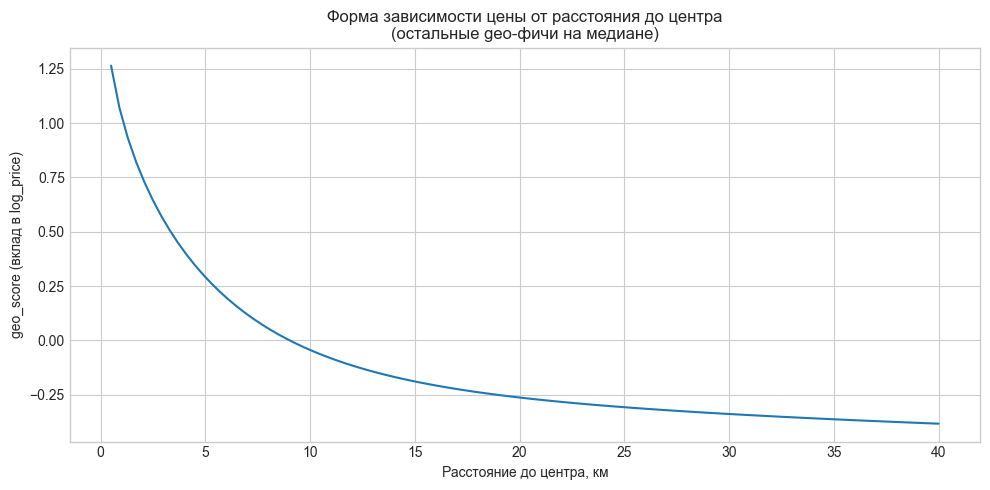

In [ ]:
# Генерим синтетическую кривую: price как функция dist_center_m
import numpy as np

test_distances = np.linspace(500, 40000, 100)
test_df_synthetic = pd.DataFrame({
    "dist_center_m": test_distances,
    "log1p_dist_center_m": np.log1p(test_distances),
    "acc_center_l5000":  np.exp(-test_distances / 5000),
    "acc_center_l12000": np.exp(-test_distances / 12000),
    "acc_center_l25000": np.exp(-test_distances / 25000),
})

# Берём только центр-фичи, остальные фиксируем на медиане train
median_features = deals.loc[train_mask, geo_num_cols].median()
full_synthetic = pd.DataFrame([median_features] * 100).reset_index(drop=True)
for col in test_df_synthetic.columns:
    full_synthetic[col] = test_df_synthetic[col].values

# Предсказываем geo_score
synthetic_pred = geo_model.predict(full_synthetic[geo_num_cols])

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(test_distances / 1000, synthetic_pred)
ax.set_xlabel("Расстояние до центра, км")
ax.set_ylabel("geo_score (вклад в log_price)")
ax.set_title("Форма зависимости цены от расстояния до центра\n(остальные geo-фичи на медиане)")
ax.grid(True)
plt.tight_layout()
plt.show()

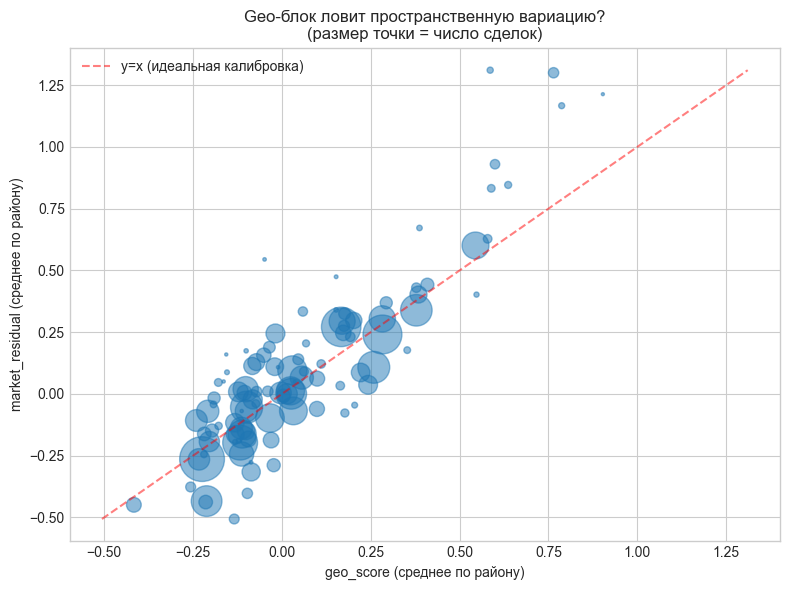

Корреляция geo_score с истинным пространственным residual: 0.875


In [ ]:
# ── График: geo_score vs district (проверяем, что geo реально ловит пространство) ──
district_geo = (
    deals.loc[train_mask]
    .groupby("district_final")
    .agg(
        market_resid_mean=("market_residual", "mean"),
        geo_score_mean=("geo_score", "mean"),
        n=("market_residual", "size"),
    )
    .query("n >= 50")
    .sort_values("market_resid_mean")
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(district_geo["geo_score_mean"], district_geo["market_resid_mean"],
           s=district_geo["n"]/20, alpha=0.5)
mn = min(district_geo["geo_score_mean"].min(), district_geo["market_resid_mean"].min())
mx = max(district_geo["geo_score_mean"].max(), district_geo["market_resid_mean"].max())
ax.plot([mn, mx], [mn, mx], "r--", alpha=0.5, label="y=x (идеальная калибровка)")
ax.set_xlabel("geo_score (среднее по району)")
ax.set_ylabel("market_residual (среднее по району)")
ax.set_title("Geo-блок ловит пространственную вариацию?\n(размер точки = число сделок)")
ax.legend()
plt.tight_layout()
plt.show()

corr = district_geo[["market_resid_mean", "geo_score_mean"]].corr().iloc[0, 1]
print(f"Корреляция geo_score с истинным пространственным residual: {corr:.3f}")

In [ ]:
# ── Moran's I — пространственная автокорреляция geo-остатков ────────────
# Проверяем, остались ли пространственные паттерны в resid_after_geo.
# Если I > 0 и значимо — geo-блок не полностью убрал пространственный сигнал.
# Реализация без libpysal: k-NN веса на выборке.

from sklearn.neighbors import BallTree as _BT

MORAN_N    = 20_000   # размер выборки (полный датасет слишком тяжёл для W-матрицы)
MORAN_K    = 8        # k ближайших соседей для весовой матрицы

# Берём train-сделки с координатами
moran_pool = deals.loc[
    train_mask & deals['building_lat'].notna() & deals['building_lon'].notna()
].sample(min(MORAN_N, train_mask.sum()), random_state=42)

coords_m = np.radians(moran_pool[['building_lat', 'building_lon']].values.astype(float))
z = moran_pool['resid_after_geo'].values
z = z - z.mean()  # центрируем
n = len(z)

# k-NN веса (row-standardized)
tree_m = _BT(coords_m, metric='haversine', leaf_size=40)
dists, idxs = tree_m.query(coords_m, k=MORAN_K + 1)  # +1 включает self
idxs = idxs[:, 1:]  # убираем self

# Moran's I = (n / S0) * (sum_ij w_ij * z_i * z_j) / (sum_i z_i^2)
# Row-standardized: w_ij = 1/k для k соседей -> S0 = n
lag = np.array([z[idxs[i]].mean() for i in range(n)])  # пространственный лаг
I_moran = (n / n) * np.sum(z * lag) / np.sum(z ** 2)

# Аналитическое ожидание и дисперсия (randomization assumption)
E_I = -1 / (n - 1)
S0 = n  # row-standardized
S1 = n * 2 / MORAN_K
S2 = n * (2 / MORAN_K) ** 2
n2 = n * n
m2 = np.sum(z ** 2) / n
m4 = np.sum(z ** 4) / n
b2 = m4 / (m2 ** 2)
var_I = (
    n * ((n**2 - 3*n + 3)*S1 - n*S2 + 3*S0**2)
    - b2 * ((n**2 - n)*S1 - 2*n*S2 + 6*S0**2)
) / ((n-1)*(n-2)*(n-3)*S0**2) - E_I**2

z_score = (I_moran - E_I) / (var_I ** 0.5)
from scipy import stats as _st
p_moran = 2 * (1 - _st.norm.cdf(abs(z_score)))

print("=== Moran's I — пространственная автокорреляция resid_after_geo ===")
print(f"  n (выборка)  : {n:,}")
print(f"  k соседей    : {MORAN_K}")
print(f"  Moran's I    : {I_moran:.4f}  (E[I]={E_I:.4f})")
print(f"  z-score      : {z_score:.4f}")
print(f"  p-value      : {p_moran:.4f}")
if p_moran < 0.05:
    if I_moran > 0:
        print("  -> FAIL: положительная пространственная автокорреляция")
        print("           geo-блок не полностью убрал пространственный сигнал")
    else:
        print("  -> FAIL: отрицательная пространственная автокорреляция")
else:
    print("  -> PASS: пространственная автокорреляция отсутствует")

# Сравнение: Moran's I до и после geo-блока
z_before = moran_pool['market_residual'].values
z_before = z_before - z_before.mean()
lag_before = np.array([z_before[idxs[i]].mean() for i in range(n)])
I_before = np.sum(z_before * lag_before) / np.sum(z_before ** 2)
print(f"\n  Moran's I до geo-блока  (market_residual) : {I_before:.4f}")
print(f"  Moran's I после geo-блока (resid_after_geo): {I_moran:.4f}")
print(f"  Снижение: {100*(1 - abs(I_moran)/abs(I_before)):.1f}%")


=== Moran's I — пространственная автокорреляция resid_after_geo ===
  n (выборка)  : 20,000
  k соседей    : 8
  Moran's I    : 0.5631  (E[I]=-0.0001)
  z-score      : 159.2586
  p-value      : 0.0000
  -> FAIL: положительная пространственная автокорреляция
           geo-блок не полностью убрал пространственный сигнал

  Moran's I до geo-блока  (market_residual) : 0.7843
  Moran's I после geo-блока (resid_after_geo): 0.5631
  Снижение: 28.2%


## 7. Блок 3 — Quality block (без geo, без district)

Теперь quality-модель видит **только фичи объекта и проекта**. Регрессирует `resid_after_geo` — то, что осталось после market + geo.

Набор фичей:
- объектные: площадь, этаж, комнаты, потолки
- проектные: возраст, стадия, масштаб, застройщик
- нет geo, нет district (они уже объяснены)

In [ ]:
# ── Подготовка фичей объекта ─────────────────────────────────────────────
deals["rooms_num"]       = deals["rooms"].fillna(deals["rooms"].median())
deals["ceiling_m_final"] = deals["ceiling_m_pd"]
deals["floor_rel"]       = deals["floor"] / deals["floor_max_pd"].replace(0, np.nan)
deals["floor_rel"]       = deals["floor_rel"].replace([np.inf, -np.inf], np.nan)

# ── Только объектные и проектные фичи ───────────────────────────────────
quality_num_cols = [
    "area_sqm", "floor", "floor_rel", "rooms_num", "ceiling_m_final",
    "project_age_months", "months_to_rve", "lots_total",
    "area_project_total", "area_project_mean", "area_project_median",
]

quality_cat_cols = [
    "class_final", "construction_type_final", "finishing",
    # developer_final, builder_final — УБИРАЕМ, их роль возьмёт project_premium
]

deals = sanitize_for_sklearn(deals, quality_num_cols, quality_cat_cols)

quality_preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ]), quality_num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe",     OneHotEncoder(handle_unknown="ignore", min_frequency=10)),
    ]), quality_cat_cols),
])

quality_model = Pipeline([
    ("prep", quality_preprocess),
    ("reg",  RidgeCV(alphas=np.logspace(-3, 3, 15))),
])

# ── Fit на train, target = resid_after_geo ──────────────────────────────
quality_model.fit(
    deals.loc[train_mask, quality_num_cols + quality_cat_cols],
    deals.loc[train_mask, "resid_after_geo"],
)

deals["quality_score"]        = quality_model.predict(deals[quality_num_cols + quality_cat_cols])
deals["resid_after_quality"]  = deals["resid_after_geo"] - deals["quality_score"]

# ── Диагностика ─────────────────────────────────────────────────────────
r2_q_train = r2_score(deals.loc[train_mask, "resid_after_geo"], deals.loc[train_mask, "quality_score"])
r2_q_test  = r2_score(deals.loc[test_mask, "resid_after_geo"],  deals.loc[test_mask, "quality_score"])
print(f"R² quality на resid_after_geo:")
print(f"  train: {r2_q_train:.4f}")
print(f"  test : {r2_q_test:.4f}")
print(f"\nRidge alpha: {quality_model.named_steps['reg'].alpha_}")

std_before = deals.loc[train_mask, "resid_after_geo"].std()
std_after  = deals.loc[train_mask, "resid_after_quality"].std()
print(f"\nSTD остатков (train):")
print(f"  до quality:  {std_before:.4f}")
print(f"  после:       {std_after:.4f}")
print(f"  снижение:     {(1 - std_after/std_before)*100:.1f}%")

R² quality на resid_after_geo:
  train: 0.2809
  test : 0.1822

Ridge alpha: 0.3727593720314938

STD остатков (train):
  до quality:  0.2214
  после:       0.1877
  снижение:     15.2%


## 8. Блок 4 — Project premium (shrinkage)

Empirical Bayes shrinkage на остатках после всех предыдущих блоков:

$$\pi_j = \frac{n_j}{n_j + \tau}\, \bar r_j$$

Обязательно считаем средние остатки **только на train**, чтобы не утечь будущее.

In [ ]:
PROJECT_PREMIUM_TAU = 20

# Агрегаты проекта только на train
proj_resid = (
    deals.loc[train_mask]
    .groupby("project_id", as_index=False)
    .agg(
        project_resid_mean=("resid_after_quality", "mean"),
        project_obs=("resid_after_quality", "size"),
        project_name=("project_name", mode_or_nan),
    )
)
proj_resid["project_premium"] = (
    proj_resid["project_obs"] / (proj_resid["project_obs"] + PROJECT_PREMIUM_TAU)
) * proj_resid["project_resid_mean"]

# Мёржим на все данные
deals = deals.drop(columns=[c for c in ["project_obs", "project_premium"] if c in deals.columns])
deals = deals.merge(
    proj_resid[["project_id", "project_obs", "project_premium"]],
    on="project_id", how="left"
)
# Для новых проектов в test (которых не было в train) — premium = 0
deals["project_premium"] = deals["project_premium"].fillna(0.0)
deals["project_obs"]     = deals["project_obs"].fillna(0)

print(f"Проектов с premium: {proj_resid.shape[0]}")
print(f"\nТоп премиальных проектов:")
display(proj_resid.sort_values("project_premium", ascending=False).head(5))
print(f"\nТоп дискаунт-проектов:")
display(proj_resid.sort_values("project_premium", ascending=True).head(5))

Проектов с premium: 508

Топ премиальных проектов:


,project_id,project_resid_mean,project_obs,project_name,project_premium
224,6d32ebc74e6bdb6bf370abe507a8504d,0.931555,53,Клубный дом на Котельнической набережной / Кот...,0.676334
189,5a828591b01f619a995363b917f10ffa,0.872916,34,River Residence / BOR (Бор),0.549614
15,08f168596ed92915f1045705e4e18ede,0.566956,344,Wellton Park,0.535805
253,79d45cdc717eb6935203cc19cb5e2ca6,0.779758,42,Carre Blanc,0.528223
129,3eb8e64c150a32ccdffe8dda8685e45d,0.670705,57,Аристократ,0.496496



Топ дискаунт-проектов:


,project_id,project_resid_mean,project_obs,project_name,project_premium
214,66bd9b9701f24489a038b4818b249405,-0.548742,158,Nord,-0.487085
289,8b8be3a7ea854f80b6fe067e28f4ce75,-0.528093,141,MONODOM Family,-0.462491
107,313ac6ae0ec8d8a36ee7441fef95e185,-0.465045,726,Зеленый Парк,-0.452578
245,751f7dc138f4b6be46b629d716c3d0b3,-0.461795,164,Квартал 38А. Prizma,-0.411600
371,bc99b3f97b222b42fa23958fe57088cc,-0.404061,522,Нахимов,-0.389151


In [ ]:
# Сколько сделок в test имеют premium (обучен на train), а сколько — нет?
test_with_premium = deals.loc[test_mask, "project_obs"] > 0
print(f"Test сделок всего: {test_mask.sum():,}")
print(f"  с project_premium (проект был в train): {test_with_premium.sum():,} ({100*test_with_premium.mean():.1f}%)")
print(f"  без premium (новые проекты): {(~test_with_premium).sum():,} ({100*(~test_with_premium).mean():.1f}%)")

# Распределение project_premium на test
print("\nРаспределение project_premium на test:")
print(deals.loc[test_mask, "project_premium"].describe().round(3))

Test сделок всего: 231,839
  с project_premium (проект был в train): 173,192 (74.7%)
  без premium (новые проекты): 58,647 (25.3%)

Распределение project_premium на test:
count    231839.000
mean          0.005
std           0.122
min          -0.462
25%          -0.039
50%           0.000
75%           0.048
max           0.550
Name: project_premium, dtype: float64


## 9. Диагностика: вклад каждого блока

Смотрим, как падает ошибка после добавления каждого блока.

In [ ]:
# ── Пошаговые предсказания ──────────────────────────────────────────────
diag = deals.loc[test_mask, ["log_price_sqm", "market_log_price",
                              "geo_score", "quality_score", "project_premium"]].copy()

diag["pred_market"]                 = diag["market_log_price"]
diag["pred_market_geo"]             = diag["pred_market"] + diag["geo_score"]
diag["pred_market_geo_quality"]     = diag["pred_market_geo"] + diag["quality_score"]
diag["pred_additive_all"]           = diag["pred_market_geo_quality"] + diag["project_premium"]

diag_metrics = pd.concat([
    regression_metrics(diag["log_price_sqm"], diag["pred_market"],             "market"),
    regression_metrics(diag["log_price_sqm"], diag["pred_market_geo"],         "+ geo"),
    regression_metrics(diag["log_price_sqm"], diag["pred_market_geo_quality"], "+ quality"),
    regression_metrics(diag["log_price_sqm"], diag["pred_additive_all"],       "+ project_premium"),
], ignore_index=True)

print("Вклад блоков (test):")
display(diag_metrics)

# ── Абсолютное улучшение от каждого блока ────────────────────────────
print("\nDelta R² от каждого блока:")
for i in range(1, len(diag_metrics)):
    delta = diag_metrics.loc[i, "R2"] - diag_metrics.loc[i-1, "R2"]
    name = diag_metrics.loc[i, "model"]
    print(f"  {name:25s}  Δ R² = {delta:+.4f}")

Вклад блоков (test):


,model,MAE_log,RMSE_log,R2,MAE_pct_approx,RMSE_pct_approx
0,market,0.256178,0.339024,0.077082,29.198316,40.357736
1,+ geo,0.208892,0.269335,0.417512,23.231149,30.909359
2,+ quality,0.187065,0.243550,0.523701,20.570597,27.577062
3,+ project_premium,0.156440,0.208794,0.649945,16.934026,23.219080



Delta R² от каждого блока:
  + geo                      Δ R² = +0.3404
  + quality                  Δ R² = +0.1062
  + project_premium          Δ R² = +0.1262


## 10. k-NN ценовые фичи (leakage-safe)

Для каждой сделки считаем статистики `log_price_sqm` **прошлых** соседей
в радиусах 500 / 1000 / 2000 м.
`deal_date` строго меньше текущей — утечки будущего нет.
`market_log_price` не используется — forward prognosis сохраняется.

In [ ]:
# ── k-NN ценовые фичи (leakage-safe) ───────────────────────────────────
# Результат кешируется в data/knn_cache_{REGION_KEY}.parquet
# Удали файл кеша если изменил KNN_RADII_M или KNN_LOOKBACK_Q

from sklearn.neighbors import BallTree
from tqdm.notebook import tqdm

EARTH_RADIUS_M = 6_371_000
KNN_RADII_M    = [500, 1000, 2000]
KNN_LOOKBACK_Q = 6   # брать соседей только за последние N кварталов

KNN_CACHE_PATH = PROJECT_DIR / "data" / f"knn_cache_{REGION_KEY}.parquet"
knn_feat_cols  = [f"knn_{stat}_{r}m" for r in KNN_RADII_M for stat in ["count", "mean", "std"]]

if KNN_CACHE_PATH.exists():
    print(f"Загружаем k-NN из кеша: {KNN_CACHE_PATH}")
    knn_cached = pd.read_parquet(KNN_CACHE_PATH)
    for col in knn_feat_cols:
        deals[col] = knn_cached[col].values
    print(f"Загружено {len(knn_feat_cols)} фич из кеша")
else:
    print("Кеш не найден — вычисляем k-NN...")
    MAX_R_RAD   = max(KNN_RADII_M) / EARTH_RADIUS_M

    valid_coord = deals["building_lat"].notna() & deals["building_lon"].notna()
    print(f"Строк с координатами: {valid_coord.sum():,} / {len(deals):,}")

    valid_idx   = np.where(valid_coord)[0]
    coords_rad  = np.radians(
        deals.loc[valid_coord, ["building_lat", "building_lon"]].values.astype(float)
    )
    dates_arr       = deals["deal_date"].values
    log_price_arr   = deals["log_price_sqm"].values
    quarter_idx_arr = deals["quarter_idx"].values

    ball_tree = BallTree(coords_rad, metric="haversine", leaf_size=40)

    knn_count = {r: np.zeros(len(deals), dtype=np.int32) for r in KNN_RADII_M}
    knn_mean  = {r: np.full(len(deals), np.nan)           for r in KNN_RADII_M}
    knn_std   = {r: np.full(len(deals), np.nan)           for r in KNN_RADII_M}

    BATCH = 2000
    for batch_start in tqdm(range(0, len(valid_idx), BATCH), desc="k-NN features"):
        batch_vidx = valid_idx[batch_start:batch_start + BATCH]
        batch_cidx = np.arange(batch_start, min(batch_start + BATCH, len(valid_idx)))

        nbr_lists, dist_lists = ball_tree.query_radius(
            coords_rad[batch_cidx],
            r=MAX_R_RAD,
            return_distance=True,
            sort_results=False,
        )

        for orig_i, nbrs_cidx, dists in zip(batch_vidx, nbr_lists, dist_lists):
            nbrs_didx = valid_idx[nbrs_cidx]
            curr_qidx = quarter_idx_arr[orig_i]
            past = (
                (dates_arr[nbrs_didx] < dates_arr[orig_i])
                & (nbrs_didx != orig_i)
                & (quarter_idx_arr[nbrs_didx] >= curr_qidx - KNN_LOOKBACK_Q)
            )
            if not past.any():
                continue

            past_dist_m = dists[past] * EARTH_RADIUS_M
            past_p      = log_price_arr[nbrs_didx[past]]

            for r in KNN_RADII_M:
                within = past_dist_m <= r
                if within.any():
                    p = past_p[within]
                    knn_count[r][orig_i] = len(p)
                    knn_mean[r][orig_i]  = p.mean()
                    knn_std[r][orig_i]   = p.std() if len(p) > 1 else 0.0

    # Добавляем фичи и сохраняем кеш
    cache_df = pd.DataFrame(index=deals.index)
    for r in KNN_RADII_M:
        deals[f"knn_count_{r}m"] = knn_count[r]
        deals[f"knn_mean_{r}m"]  = knn_mean[r]
        deals[f"knn_std_{r}m"]   = knn_std[r]
        cache_df[f"knn_count_{r}m"] = knn_count[r]
        cache_df[f"knn_mean_{r}m"]  = knn_mean[r]
        cache_df[f"knn_std_{r}m"]   = knn_std[r]

    cache_df.to_parquet(KNN_CACHE_PATH, index=False)
    print(f"Кеш сохранён: {KNN_CACHE_PATH}")

print("k-NN фичи:")
for r in KNN_RADII_M:
    n_valid = (deals[f"knn_count_{r}m"] > 0).sum()
    avg_n   = int(deals.loc[deals[f"knn_count_{r}m"] > 0, f"knn_count_{r}m"].mean()) if n_valid else 0
    print(f"  {r:5d}m: {n_valid:,} сделок ({100*n_valid/len(deals):.1f}%), ср. {avg_n} соседей")


Загружаем k-NN из кеша: C:\cashflow_project\data\knn_cache_Moscow.parquet
Загружено 9 фич из кеша
k-NN фичи:
    500m: 535,848 сделок (92.8%), ср. 1109 соседей
   1000m: 536,109 сделок (92.8%), ср. 1354 соседей
   2000m: 537,732 сделок (93.1%), ср. 2276 соседей


## 11. H3 target encoding (leakage-safe)

H3 гексагоны resolution 8 (~460м) и 9 (~170м) с Empirical Bayes shrinkage.
Заменяет грубые `district_final` dummy (~145 OHE колонок) на плавный пространственный сигнал.
Энкодинг считается **только на train**, применяется на все данные.

In [ ]:
# ── H3 target encoding (leakage-safe) ───────────────────────────────────
import h3 as h3lib

H3_RESOLUTIONS = [8, 9]   # ~460м и ~170м
H3_TAU         = 10       # shrinkage параметр

# Вычисляем H3 индексы
for res in H3_RESOLUTIONS:
    col = f'h3_r{res}'
    deals[col] = [
        h3lib.latlng_to_cell(lat, lon, res)
        if pd.notna(lat) and pd.notna(lon) else None
        for lat, lon in zip(deals['building_lat'], deals['building_lon'])
    ]
    print(f'H3 res={res}: {deals[col].nunique():,} уникальных гексагонов')

h3_encoder_maps = {}   # res -> pd.Series (h3_cell_id -> encoded_value)

# EB shrinkage encoding на resid_after_geo (train only)
# resid_after_geo ортогонален geo_score → H3 несёт новый пространственный сигнал
global_mean = deals.loc[train_mask, 'resid_after_geo'].mean()
h3_enc_cols = []

for res in H3_RESOLUTIONS:
    col     = f'h3_r{res}'
    enc_col = f'h3_enc_r{res}'

    stats = (
        deals.loc[train_mask]
        .groupby(col)['resid_after_geo']
        .agg(h3_mean='mean', h3_n='count')
    )
    stats[enc_col] = (
        stats['h3_n'] / (stats['h3_n'] + H3_TAU) * stats['h3_mean']
        + H3_TAU     / (stats['h3_n'] + H3_TAU) * global_mean
    )

    deals = deals.drop(columns=[enc_col], errors='ignore')
    deals = deals.merge(stats[[enc_col]], on=col, how='left')
    deals[enc_col] = deals[enc_col].fillna(global_mean)
    h3_enc_cols.append(enc_col)
    h3_encoder_maps[res] = stats[enc_col].copy()

    train_hexes = set(deals.loc[train_mask, col].dropna())
    test_hexes  = set(deals.loc[test_mask,  col].dropna())
    new_hexes   = test_hexes - train_hexes
    print(f'  res={res}: {len(train_hexes):,} train / {len(test_hexes):,} test, '
          f'{len(new_hexes):,} новых в test ({100*len(new_hexes)/max(len(test_hexes),1):.1f}%)')

print(f'H3 фичи: {h3_enc_cols}')

h3_encoder = {
    "resolutions": H3_RESOLUTIONS,
    "tau": H3_TAU,
    "global_mean": global_mean,
    "encodings": h3_encoder_maps,   # {8: pd.Series, 9: pd.Series}
}
print(f'Std h3_enc_r8  (train): {deals.loc[train_mask, "h3_enc_r8"].std():.4f}')
print(f'Std h3_enc_r9  (train): {deals.loc[train_mask, "h3_enc_r9"].std():.4f}')
print(f'Std geo_score  (train): {deals.loc[train_mask, "geo_score"].std():.4f}  (для сравнения)')


H3 res=8: 363 уникальных гексагонов
H3 res=9: 455 уникальных гексагонов
  res=8: 306 train / 257 test, 57 новых в test (22.2%)
  res=9: 366 train / 297 test, 89 новых в test (30.0%)
H3 фичи: ['h3_enc_r8', 'h3_enc_r9']
Std h3_enc_r8  (train): 0.1506
Std h3_enc_r9  (train): 0.1547
Std geo_score  (train): 0.2254  (для сравнения)


## 12. Residual LightGBM — нелинейный финальный блок

Бустинг обучается на **остатках** аддитивного backbone (`base_pred`).
**Критично**: `market_log_price` и макро-фичи **НЕ** входят в LightGBM —
это сохраняет возможность forward prognosis через линейный market-блок.

In [ ]:
# ── Аддитивный backbone ──────────────────────────────────────────────────
deals["base_pred"] = (
    deals["market_log_price"]   # экстраполируется через macro/trend
    + deals["geo_score"]        # стабильный во времени, линейный по POI
    + deals["quality_score"]    # стабильный во времени, линейный по объекту
    + deals["project_premium"]  # EB shrinkage
)
deals["lgb_residual"] = deals["log_price_sqm"] - deals["base_pred"]

r2_backbone_train = r2_score(deals.loc[train_mask, "log_price_sqm"], deals.loc[train_mask, "base_pred"])
r2_backbone_test  = r2_score(deals.loc[test_mask,  "log_price_sqm"], deals.loc[test_mask,  "base_pred"])
print(f"R² backbone (train): {r2_backbone_train:.4f}")
print(f"R² backbone (test) : {r2_backbone_test:.4f}")
print(f"Residual std (train): {deals.loc[train_mask, 'lgb_residual'].std():.4f}")
print(f"Residual std (test) : {deals.loc[test_mask,  'lgb_residual'].std():.4f}")


R² backbone (train): 0.9078
R² backbone (test) : 0.6499
Residual std (train): 0.1207
Residual std (test) : 0.2086


In [ ]:
# ── Скользящее окно для LightGBM ────────────────────────────────────────
# Backbone обучен на ВСЁМ train. LightGBM — только на последних N кварталах:
# паттерны остатков меняются со временем, старые данные могут мешать.
# ROLLING_WINDOW_Q = None → использовать весь train.

ROLLING_WINDOW_Q = 12  # последние N кварталов train (~3 года)

if ROLLING_WINDOW_Q is not None:
    rolling_quarters = set(sorted(train_quarters)[-ROLLING_WINDOW_Q:])
    lgb_train_mask   = deals['quarter'].isin(rolling_quarters)
    print(f'Rolling window: {sorted(rolling_quarters)[0]} → {sorted(rolling_quarters)[-1]}')
    print(f'LGB train rows: {lgb_train_mask.sum():,} из {train_mask.sum():,} ({100*lgb_train_mask.sum()/train_mask.sum():.0f}%)')
else:
    lgb_train_mask = train_mask
    print('Rolling window: отключено, используется весь train')

# Фичи для бустинга: объектные + пространственные
# КРИТИЧНО: market_log_price и макро-фичи НЕ включаются
lgb_features_num = [
    c for c in (
        ["area_sqm", "floor", "floor_rel", "rooms_num", "ceiling_m_final",
         "project_age_months", "months_to_rve", "lots_total",
         "area_project_total", "area_project_mean", "area_project_median"]
        + dist_cols
        + [f"log1p_{c}" for c in dist_cols]
        + [f"geo_pc{i+1}" for i in range(5)]
        + ["acc_transit", "acc_family", "acc_retail_green", "acc_centrality",
           "geo_score", "quality_score"]
        + knn_feat_cols
        + h3_enc_cols
    )
    if c in deals.columns
]

lgb_features_cat = [c for c in ["class_final", "construction_type_final", "finishing"]
                    if c in deals.columns]

print(f"LGB num features: {len(lgb_features_num)}")
print(f"LGB cat features: {lgb_features_cat}")

X_train_lgb = deals.loc[lgb_train_mask, lgb_features_num + lgb_features_cat].copy()
X_test_lgb  = deals.loc[test_mask,      lgb_features_num + lgb_features_cat].copy()
for col in lgb_features_cat:
    X_train_lgb[col] = X_train_lgb[col].astype("category")
    X_test_lgb[col]  = X_test_lgb[col].astype("category")

y_train_resid = deals.loc[lgb_train_mask, "lgb_residual"]
y_test_resid  = deals.loc[test_mask,       "lgb_residual"]

lgb_model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=30,
    reg_alpha=0.1,
    reg_lambda=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

lgb_model.fit(
    X_train_lgb, y_train_resid,
    eval_set=[(X_test_lgb, y_test_resid)],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(200)],
    categorical_feature=lgb_features_cat,
)

X_all_lgb = deals[lgb_features_num + lgb_features_cat].copy()
for col in lgb_features_cat:
    X_all_lgb[col] = X_all_lgb[col].astype("category")

deals["lgb_boost"]      = lgb_model.predict(X_all_lgb)
deals["final_pred_lgb"] = deals["base_pred"] + deals["lgb_boost"]

metrics_lgb = pd.concat([
    regression_metrics(deals.loc[test_mask, "log_price_sqm"],
                       deals.loc[test_mask, "base_pred"],        "backbone (additive)"),
    regression_metrics(deals.loc[test_mask, "log_price_sqm"],
                       deals.loc[test_mask, "final_pred_lgb"],   "backbone + LightGBM"),
], ignore_index=True)
display(metrics_lgb)
print(f"Best iteration: {lgb_model.best_iteration_}")


Rolling window: 2019Q4 → 2022Q3
LGB train rows: 185,659 из 345,566 (54%)
LGB num features: 51
LGB cat features: ['class_final', 'construction_type_final', 'finishing']


,model,MAE_log,RMSE_log,R2,MAE_pct_approx,RMSE_pct_approx
0,backbone (additive),0.15644,0.208794,0.649945,16.934026,23.219080
1,backbone + LightGBM,0.15105,0.200702,0.676550,16.305511,22.226097


Best iteration: 75


## 13. Диагностика экстраполяции

Проверяем, что LightGBM не «видит» market-сигнал неявно.
Стандартные метрики MAE/R² не показывают этот дефект — нужны явные тесты.

In [ ]:
# ── Тест 1: forced out-of-range shift ────────────────────────────────────
# Сдвигаем base_pred на +0.20 (~22% роста цен) и смотрим на изменение прогноза.
# Если архитектура правильная: delta == 0.20 везде (бустинг не зависит от market).

lgb_pred_test    = lgb_model.predict(X_test_lgb)
base_pred_normal = deals.loc[test_mask, "base_pred"].values

pred_normal  = base_pred_normal + lgb_pred_test
pred_shifted = (base_pred_normal + 0.20) + lgb_pred_test  # бустинг НЕ пересчитываем
delta = pred_shifted - pred_normal

print("=== Тест 1: forced out-of-range shift (+0.20 на base_pred) ===")
print(f"Mean delta : {delta.mean():.6f}  (ожидаем 0.200000)")
print(f"Std delta  : {delta.std():.8f}  (ожидаем ~0)")
print(f"Min / Max  : [{delta.min():.6f}, {delta.max():.6f}]")

if abs(delta.mean() - 0.20) < 1e-6 and delta.std() < 1e-6:
    print("\n✓ PASS: residual-архитектура работает, экстраполяция сквозная")
else:
    print("\n✗ FAIL: где-то утечка — бустинг видит market_log_price неявно")

# ── Тест 3: sanity check на сценариях ────────────────────────────────────
# Прогноз должен монотонно расти при увеличении market_log_price (снижении ставки).

sample_idx = deals.loc[test_mask].index[:5]
lgb_sample = deals.loc[sample_idx, lgb_features_num + lgb_features_cat].copy()
for col in lgb_features_cat:
    lgb_sample[col] = lgb_sample[col].astype("category")
lgb_boost_sample = lgb_model.predict(lgb_sample)
base_sample      = deals.loc[sample_idx, "base_pred"].values

scenarios = {
    "shift -0.10 (рост ставки)": -0.10,
    "shift +0.00 (базовый)":      0.00,
    "shift +0.10 (умеренный)":    0.10,
    "shift +0.20 (агрессивный)":  0.20,
}

results = {name: base_sample + shift + lgb_boost_sample
           for name, shift in scenarios.items()}

df_sc = pd.DataFrame(results, index=[f"deal_{i}" for i in range(len(sample_idx))])
print("\n=== Тест 3: сценарный sanity check ===")
print(df_sc.round(4).to_string())

sorted_names = sorted(scenarios.items(), key=lambda x: x[1])
print("\nМонотонность (должно быть True для всех):")
for i in range(1, len(sorted_names)):
    prev_name, curr_name = sorted_names[i-1][0], sorted_names[i][0]
    mono_ok = (results[curr_name] > results[prev_name]).all()
    status = "✓" if mono_ok else "✗"
    print(f"  {prev_name!r} → {curr_name!r}: {status}")


=== Тест 1: forced out-of-range shift (+0.20 на base_pred) ===
Mean delta : 0.200000  (ожидаем 0.200000)
Std delta  : 0.00000000  (ожидаем ~0)
Min / Max  : [0.200000, 0.200000]

✓ PASS: residual-архитектура работает, экстраполяция сквозная

=== Тест 3: сценарный sanity check ===
        shift -0.10 (рост ставки)  shift +0.00 (базовый)  shift +0.10 (умеренный)  shift +0.20 (агрессивный)
deal_0                    12.2749                12.3749                  12.4749                    12.5749
deal_1                    12.2624                12.3624                  12.4624                    12.5624
deal_2                    12.3992                12.4992                  12.5992                    12.6992
deal_3                    12.6074                12.7074                  12.8074                    12.9074
deal_4                    12.4876                12.5876                  12.6876                    12.7876

Монотонность (должно быть True для всех):
  'shift -0.10 (рост ст

## 14. Диагностика Гаусса-Маркова

Проверяем посылки теоремы Гаусса-Маркова на остатках backbone (до LightGBM).
Тесты на **test** выборке, отсортированной по дате — для корректного DW и BG.

**Приоритеты:** автокорреляция и нулевое матожидание — обязательно.
Гетероскедастичность → Newey-West SE. Мультиколлинеарность некритична для backbone.

=== Диагностика Гаусса-Маркова (backbone residuals, test set) ===
                                    Тест      Статистика p-value Результат                        Примечание
                  E[residual]=0 (t-test)      t=-20.8992  0.0000      FAIL                     mean=-0.00905
      Гомоскедастичность — Breusch-Pagan     LM=14951.85  0.0000      FAIL         при FAIL -> Newey-West SE
    Гомоскедастичность — Goldfeld-Quandt        F=1.5482  0.0000      FAIL                                  
        Мультиколлинеарность — макс. VIF    max VIF=1.34       -      PASS                      cond(X)=3143
          Автокорреляция — Durbin-Watson       DW=1.0852       -      FAIL                     норма 1.5-2.5
Автокорреляция — Breusch-Godfrey (lag=4)      LM=1075.95  0.0000      FAIL                                  
                  Нормальность — KS-тест       KS=0.0438  0.0000      FAIL      при n>100k почти всегда FAIL
              Нормальность — Jarque-Bera      JB=42586.9  0.00

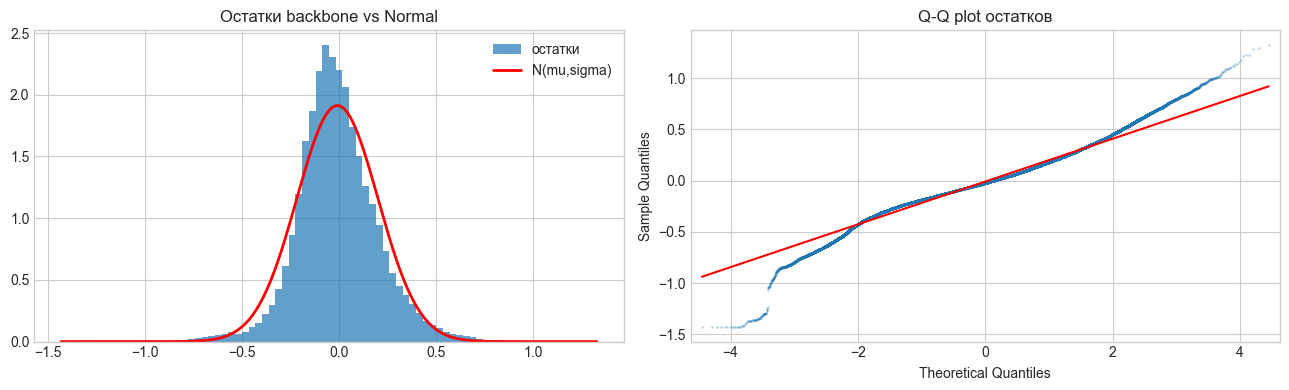

In [ ]:
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.diagnostic import (
    het_breuschpagan, het_goldfeldquandt,
    acorr_breusch_godfrey, linear_reset,
)
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Остатки backbone на test, отсортированные по дате
test_sorted = deals.loc[test_mask].sort_values('deal_date')
resid  = test_sorted['lgb_residual'].values
y_true = test_sorted['log_price_sqm'].values
y_pred = test_sorted['base_pred'].values

X_diag  = test_sorted[['market_log_price', 'geo_score', 'quality_score', 'project_premium']].fillna(0)
X_const = sm.add_constant(X_diag.values)

results = {}

# 1. Нулевое матожидание
t_stat, p_t = stats.ttest_1samp(resid, 0)
results['E[residual]=0 (t-test)'] = {
    'stat': f't={t_stat:.4f}', 'p': p_t,
    'pass': p_t > 0.05, 'note': f'mean={resid.mean():.5f}'
}

# 2. Гомоскедастичность
lm_bp, p_bp, _, _ = het_breuschpagan(resid, X_const)
results['Гомоскедастичность — Breusch-Pagan'] = {
    'stat': f'LM={lm_bp:.2f}', 'p': p_bp,
    'pass': p_bp > 0.05, 'note': 'при FAIL -> Newey-West SE'
}
gq_f, p_gq, _ = het_goldfeldquandt(y_true, X_const, alternative='two-sided')
results['Гомоскедастичность — Goldfeld-Quandt'] = {
    'stat': f'F={gq_f:.4f}', 'p': p_gq,
    'pass': p_gq > 0.05, 'note': ''
}

# 3. Мультиколлинеарность (VIF)
vif_vals = [variance_inflation_factor(X_diag.values, i) for i in range(X_diag.shape[1])]
vif_df = pd.DataFrame({'feature': X_diag.columns, 'VIF': [round(v,2) for v in vif_vals]})
cond_num = np.linalg.cond(X_const)
results['Мультиколлинеарность — макс. VIF'] = {
    'stat': f'max VIF={max(vif_vals):.2f}', 'p': None,
    'pass': max(vif_vals) < 10, 'note': f'cond(X)={cond_num:.0f}'
}

# 4. Автокорреляция
N_DW = min(20_000, len(resid))
dw = durbin_watson(resid[:N_DW])
results['Автокорреляция — Durbin-Watson'] = {
    'stat': f'DW={dw:.4f}', 'p': None,
    'pass': 1.5 < dw < 2.5, 'note': 'норма 1.5-2.5'
}
ols_fit = sm.OLS(y_true[:N_DW], X_const[:N_DW]).fit()
bg_lm, p_bg, _, _ = acorr_breusch_godfrey(ols_fit, nlags=4)
results['Автокорреляция — Breusch-Godfrey (lag=4)'] = {
    'stat': f'LM={bg_lm:.2f}', 'p': p_bg,
    'pass': p_bg > 0.05, 'note': ''
}

# 5. Нормальность
ks_stat, p_ks = stats.kstest(resid, 'norm', args=(resid.mean(), resid.std()))
results['Нормальность — KS-тест'] = {
    'stat': f'KS={ks_stat:.4f}', 'p': p_ks,
    'pass': p_ks > 0.05, 'note': 'при n>100k почти всегда FAIL'
}
jb_stat, p_jb = stats.jarque_bera(resid)
results['Нормальность — Jarque-Bera'] = {
    'stat': f'JB={jb_stat:.1f}', 'p': p_jb,
    'pass': p_jb > 0.05,
    'note': f'skew={stats.skew(resid):.3f}, kurt={stats.kurtosis(resid):.3f}'
}

# 6. RESET-тест Рэмзи
reset_res = linear_reset(ols_fit, power=3, use_f=True)
results['Спецификация — RESET (Ramsey)'] = {
    'stat': f'F={reset_res.fvalue:.4f}', 'p': reset_res.pvalue,
    'pass': reset_res.pvalue > 0.05, 'note': 'FAIL -> нелин. фичи (LGB доберет)'
}

# 7. Тест Чоу (структурный сдвиг 2022Q1)
chow_break = '2022Q1'
mask_pre  = test_sorted['quarter'] < chow_break
mask_post = test_sorted['quarter'] >= chow_break
n_pre, n_post, k = mask_pre.sum(), mask_post.sum(), X_const.shape[1]
if n_pre > k and n_post > k:
    rss_full = np.sum(sm.OLS(y_true, X_const).fit().resid ** 2)
    rss_pre  = np.sum(sm.OLS(y_true[mask_pre.values],  X_const[mask_pre.values]).fit().resid  ** 2)
    rss_post = np.sum(sm.OLS(y_true[mask_post.values], X_const[mask_post.values]).fit().resid ** 2)
    chow_f   = ((rss_full - rss_pre - rss_post) / k) / ((rss_pre + rss_post) / (len(y_true) - 2*k))
    p_chow   = 1 - stats.f.cdf(chow_f, k, len(y_true) - 2*k)
    results[f'Структурный сдвиг — Чоу ({chow_break})'] = {
        'stat': f'F={chow_f:.4f}', 'p': p_chow,
        'pass': p_chow > 0.05, 'note': 'FAIL -> рынок изменился после 2022Q1'
    }

# 8. Расстояние Кука (на выборке 5k)
N_COOK = 5_000
ols_cook = sm.OLS(y_true[:N_COOK], X_const[:N_COOK]).fit()
cooks_d = ols_cook.get_influence().cooks_distance[0]
threshold = 4 / N_COOK
n_inf = (cooks_d > threshold).sum()
results['Выбросы — Кук (5k sample)'] = {
    'stat': f'{n_inf} влиятельных', 'p': None,
    'pass': n_inf / N_COOK < 0.01,
    'note': f'порог=4/n={threshold:.5f}, {100*n_inf/N_COOK:.2f}%'
}

# Итоговая таблица
rows = []
for name, r in results.items():
    p_str = f"{r['p']:.4f}" if r['p'] is not None else '-'
    rows.append({'Тест': name, 'Статистика': r['stat'],
                 'p-value': p_str, 'Результат': 'PASS' if r['pass'] else 'FAIL',
                 'Примечание': r['note']})
diag_gm = pd.DataFrame(rows)
print('=== Диагностика Гаусса-Маркова (backbone residuals, test set) ===')
print(diag_gm.to_string(index=False))
print()
print('VIF backbone:')
print(vif_df.to_string(index=False))

# График
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(resid, bins=80, density=True, alpha=0.7, label='остатки')
x_norm = np.linspace(resid.min(), resid.max(), 300)
axes[0].plot(x_norm, stats.norm.pdf(x_norm, resid.mean(), resid.std()), 'r-', lw=2, label='N(mu,sigma)')
axes[0].set_title('Остатки backbone vs Normal')
axes[0].legend()
sm.qqplot(resid, line='s', ax=axes[1], alpha=0.2, markersize=1)
axes[1].set_title('Q-Q plot остатков')
plt.tight_layout()
plt.show()


## 15. Оценка и визуализация

Median APE: 0.1232
Mean APE  : 0.1602
P90 APE   : 0.3228


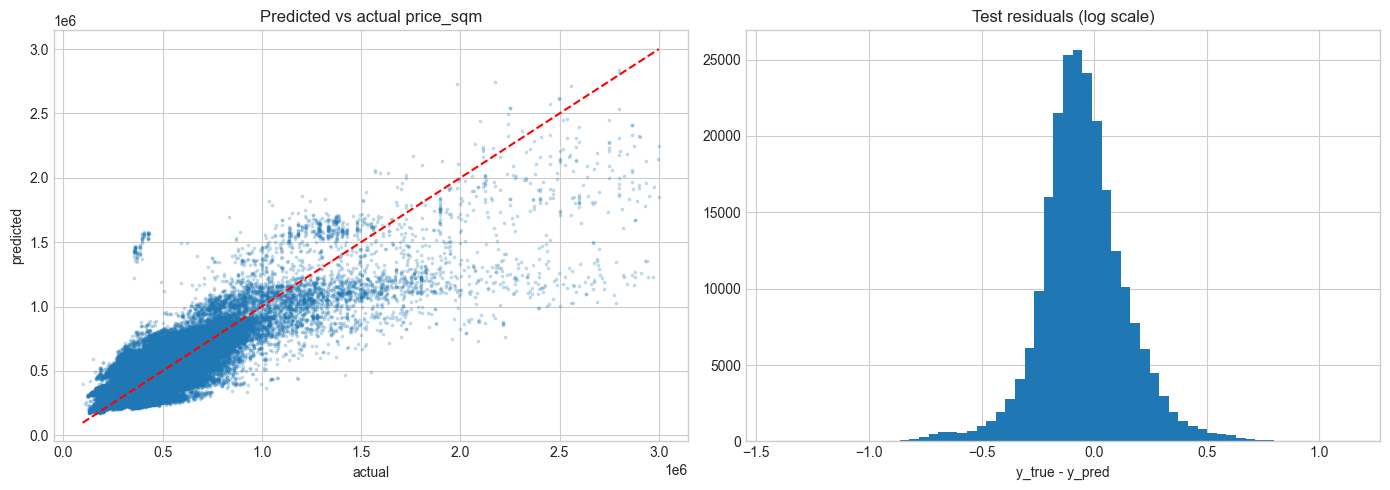

In [ ]:
test_eval = deals.loc[test_mask, [
    "project_name", "district_final", "quarter",
    "price_sqm", "market_log_price", "geo_score", "quality_score", "project_premium"
]].copy()
test_eval["pred_log_price_sqm"] = deals.loc[test_mask, "final_pred_lgb"].values
test_eval["pred_price_sqm"]     = np.exp(test_eval["pred_log_price_sqm"])
test_eval["ape"] = (test_eval["pred_price_sqm"] - test_eval["price_sqm"]).abs() / test_eval["price_sqm"]

print(f"Median APE: {test_eval['ape'].median():.4f}")
print(f"Mean APE  : {test_eval['ape'].mean():.4f}")
print(f"P90 APE   : {test_eval['ape'].quantile(0.9):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(test_eval["price_sqm"], test_eval["pred_price_sqm"], alpha=0.2, s=3)
mn = min(test_eval["price_sqm"].min(), test_eval["pred_price_sqm"].min())
mx = max(test_eval["price_sqm"].max(), test_eval["pred_price_sqm"].max())
axes[0].plot([mn, mx], [mn, mx], "r--")
axes[0].set_title("Predicted vs actual price_sqm")
axes[0].set_xlabel("actual")
axes[0].set_ylabel("predicted")

resid = deals.loc[test_mask, "log_price_sqm"].values - deals.loc[test_mask, "final_pred_lgb"].values
axes[1].hist(resid, bins=60)
axes[1].set_title("Test residuals (log scale)")
axes[1].set_xlabel("y_true - y_pred")

plt.tight_layout()
plt.show()


## 16. Сохранение артефактов

In [ ]:
import pickle

ARTIFACTS_DIR = PROJECT_DIR / "data" / "model_artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Сохраняем модели
with open(ARTIFACTS_DIR / f"geo_model_{REGION_KEY}.pkl", "wb") as f:
    pickle.dump(geo_model, f)

with open(ARTIFACTS_DIR / f"quality_model_{REGION_KEY}.pkl", "wb") as f:
    pickle.dump(quality_model, f)

with open(ARTIFACTS_DIR / f"pca_geo_{REGION_KEY}.pkl", "wb") as f:
    pickle.dump({"pca": pca_geo, "scaler": pca_scaler, "input_cols": pca_input_cols}, f)

with open(ARTIFACTS_DIR / f"h3_encoder_{REGION_KEY}.pkl", "wb") as f:
    pickle.dump(h3_encoder, f)
print(f"  h3_encoder_{REGION_KEY}.pkl saved ({len(h3_encoder['encodings'])} resolutions)")

with open(ARTIFACTS_DIR / f"lgb_residual_model_{REGION_KEY}.pkl", "wb") as f:
    pickle.dump({"model": lgb_model, "features_num": lgb_features_num, "features_cat": lgb_features_cat}, f)

proj_resid.to_parquet(ARTIFACTS_DIR / f"project_premium_{REGION_KEY}.parquet", index=False)

market_index = (
    deals[["quarter", "city_log_price_median", "market_log_price"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
market_index.to_parquet(ARTIFACTS_DIR / f"market_index_{REGION_KEY}.parquet", index=False)

coefs_geo.sort_values(key=abs, ascending=False).to_csv(
    ARTIFACTS_DIR / f"geo_coefs_{REGION_KEY}.csv"
)

print(f"Артефакты сохранены в: {ARTIFACTS_DIR}")
print()
print("Финальные метрики (backbone + LightGBM):")
display(metrics_lgb)
print()
print("Вклад блоков:")
display(diag_metrics)


Артефакты сохранены в: C:\cashflow_project\data\model_artifacts

Финальные метрики (backbone + LightGBM):


,model,MAE_log,RMSE_log,R2,MAE_pct_approx,RMSE_pct_approx
0,backbone (additive),0.15644,0.208794,0.649945,16.934026,23.219080
1,backbone + LightGBM,0.15105,0.200702,0.676550,16.305511,22.226097



Вклад блоков:


,model,MAE_log,RMSE_log,R2,MAE_pct_approx,RMSE_pct_approx
0,market,0.256178,0.339024,0.077082,29.198316,40.357736
1,+ geo,0.208892,0.269335,0.417512,23.231149,30.909359
2,+ quality,0.187065,0.243550,0.523701,20.570597,27.577062
3,+ project_premium,0.156440,0.208794,0.649945,16.934026,23.219080
